# Credit Card Default Prediction - Exploratory Data Analysis

This notebook explores the Default of Credit Card Clients dataset.  
The goal is to understand the structure of the data, target distribution, feature behavior, and relationships before building machine learning models.

### Import libraries ###

In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### Load dataset ###

In [25]:
from pathlib import Path

DATA_PATH = "../data/raw/default of credit card clients.csv"
data_path = Path(DATA_PATH)

if not data_path.is_file():
    for base in [Path.cwd(), *Path.cwd().parents]:
        print("base",base)
        print("path",Path.cwd(), *Path.cwd().parents)
        candidate = (base / DATA_PATH).resolve()
        if candidate.is_file():
            data_path = candidate
            break
    else:
        raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")
df = pd.read_csv(data_path, header = 1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [26]:
print(f"Data shape: {df.shape}\n")
print(f"Data description: {df.describe().T}")

Data shape: (30000, 25)

Data description:                               count           mean            std       min       25%       50%        75%        max
ID                          30000.0   15000.500000    8660.398374       1.0   7500.75   15000.5   22500.25    30000.0
LIMIT_BAL                   30000.0  167484.322667  129747.661567   10000.0  50000.00  140000.0  240000.00  1000000.0
SEX                         30000.0       1.603733       0.489129       1.0      1.00       2.0       2.00        2.0
EDUCATION                   30000.0       1.853133       0.790349       0.0      1.00       2.0       2.00        6.0
MARRIAGE                    30000.0       1.551867       0.521970       0.0      1.00       2.0       2.00        3.0
AGE                         30000.0      35.485500       9.217904      21.0     28.00      34.0      41.00       79.0
PAY_0                       30000.0      -0.016700       1.123802      -2.0     -1.00       0.0       0.00        8.0
PAY_2        

### Clean column names ###

In [27]:
df.columns = df.columns.str.strip()
target_col = 'default payment next month'
print(target_col in df.columns)
print(df.columns)

True
Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month'], dtype='object')


In [28]:
df.columns.tolist()

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

### Check missing values ###

In [29]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Series([], dtype: int64)

### checking missing rows ###

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df[target_col].value_counts()

default payment next month
0    23364
1     6636
Name: count, dtype: int64

In [32]:
df[target_col].value_counts(normalize=True)

default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

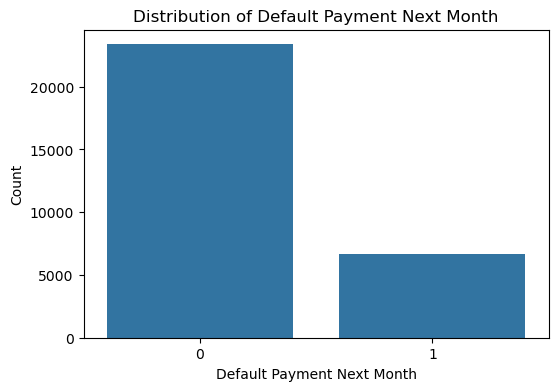

In [33]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x = target_col)
plt.title('Distribution of Default Payment Next Month')
plt.xlabel('Default Payment Next Month')
plt.ylabel('Count')
plt.show()

### Target Distribution Insight

The target variable is imbalanced. Most customers did not default, while a smaller percentage defaulted next month.  
Because of this imbalance, accuracy alone is not enough. We should also evaluate precision, recall, F1-score, and ROC-AUC.

### Rename columns for readability ###

In [34]:
rename_map = {
    "LIMIT_BAL": "credit_limit",
    "SEX": "sex",
    "EDUCATION": "education",
    "MARRIAGE": "marriage",
    "AGE": "age",
    "PAY_0": "repayment_status_sep",
    "PAY_2": "repayment_status_aug",
    "PAY_3": "repayment_status_jul",
    "PAY_4": "repayment_status_jun",
    "PAY_5": "repayment_status_may",
    "PAY_6": "repayment_status_apr",
    "BILL_AMT1": "bill_amount_sep",
    "BILL_AMT2": "bill_amount_aug",
    "BILL_AMT3": "bill_amount_jul",
    "BILL_AMT4": "bill_amount_jun",
    "BILL_AMT5": "bill_amount_may",
    "BILL_AMT6": "bill_amount_apr",
    "PAY_AMT1": "payment_amount_sep",
    "PAY_AMT2": "payment_amount_aug",
    "PAY_AMT3": "payment_amount_jul",
    "PAY_AMT4": "payment_amount_jun",
    "PAY_AMT5": "payment_amount_may",
    "PAY_AMT6": "payment_amount_apr",
    "default.payment.next.month": "default_next_month"
}

df = df.rename(columns=rename_map)

df.head()

,ID,credit_limit,sex,education,marriage,age,repayment_status_sep,repayment_status_aug,repayment_status_jul,repayment_status_jun,repayment_status_may,repayment_status_apr,bill_amount_sep,bill_amount_aug,bill_amount_jul,bill_amount_jun,bill_amount_may,bill_amount_apr,payment_amount_sep,payment_amount_aug,payment_amount_jul,payment_amount_jun,payment_amount_may,payment_amount_apr,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [35]:
target_col = "default_next_month"

### Dropping ID Column ###

In [36]:
if "ID" in df.columns:
    df = df.drop(columns=["ID"])
df.head()

,credit_limit,sex,education,marriage,age,repayment_status_sep,repayment_status_aug,repayment_status_jul,repayment_status_jun,repayment_status_may,repayment_status_apr,bill_amount_sep,bill_amount_aug,bill_amount_jul,bill_amount_jun,bill_amount_may,bill_amount_apr,payment_amount_sep,payment_amount_aug,payment_amount_jul,payment_amount_jun,payment_amount_may,payment_amount_apr,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [37]:
df = df.rename(columns = {'default payment next month': 'default_next_month'})

### Credit limit analysis ###

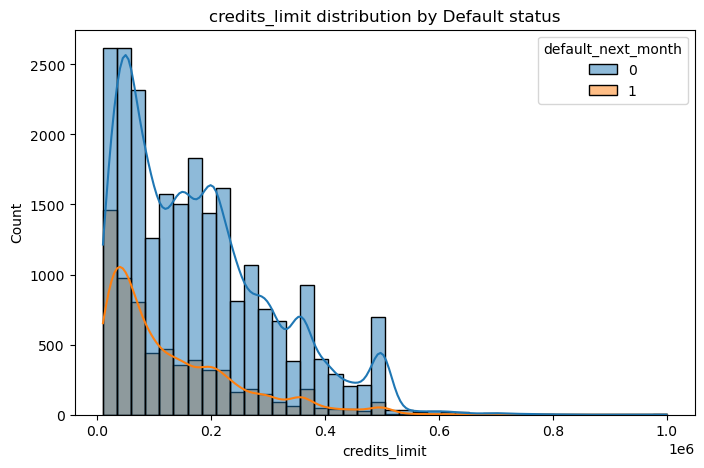

In [38]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x = 'credit_limit', hue = target_col, bins = 40, kde = True)
plt.title("credits_limit distribution by Default status")
plt.xlabel("credits_limit")
plt.ylabel("Count")
plt.show()

In [39]:
df.groupby(target_col)['credit_limit'].describe()  

,count,mean,std,min,25%,50%,75%,max
default_next_month,,,,,,,,
0,23364.0,178099.726074,131628.359660,10000.0,70000.0,150000.0,250000.0,1000000.0
1,6636.0,130109.656420,115378.540571,10000.0,50000.0,90000.0,200000.0,740000.0


In [40]:
df["credit_limit_group"] = pd.cut(
    df["credit_limit"],
    bins=[0, 50000, 100000, 200000, 300000, 500000, 1000000],
    labels=["0-50k", "50k-100k", "100k-200k", "200k-300k", "300k-500k", "500k+"]
)

df.groupby("credit_limit_group")["default_next_month"].mean() * 100

C:\Users\srima\AppData\Local\Temp\ipykernel_25892\3177960277.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("credit_limit_group")["default_next_month"].mean() * 100


credit_limit_group
0-50k        31.787389
50k-100k     25.798424
100k-200k    19.479695
200k-300k    16.050603
300k-500k    13.357815
500k+        11.165049
Name: default_next_month, dtype: float64

In [41]:
df.drop(columns=["credit_limit_group"], inplace=True)

### Credit Limit Insight

Credit limit appears to be related to default behavior. Customers with lower credit limits may show different default patterns compared to customers with higher credit limits.

### Age analysis ###

<Axes: xlabel='age', ylabel='Count'>

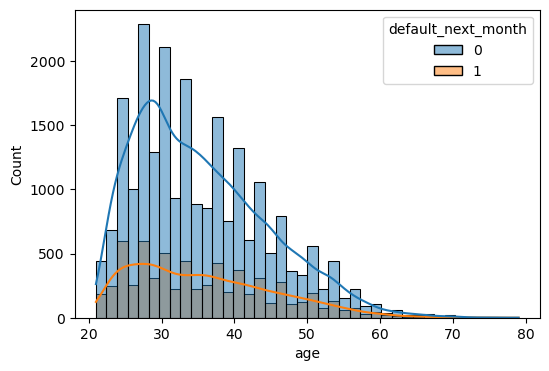

In [42]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x = 'age', hue = target_col, bins = 40, kde = True)

### Categorical feature analysis ###

In [43]:
plot_df = df.copy()
plot_df[target_col] = plot_df[target_col].map({
    0: 'No Default', 1: 'Default'
    })


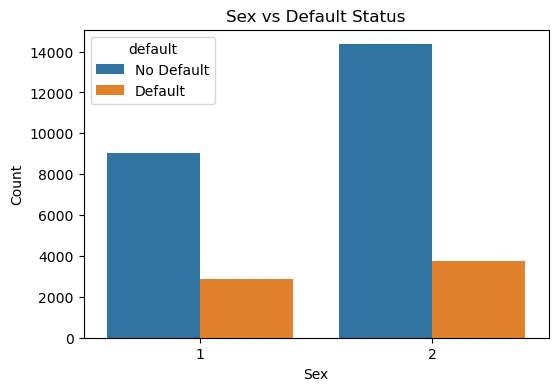

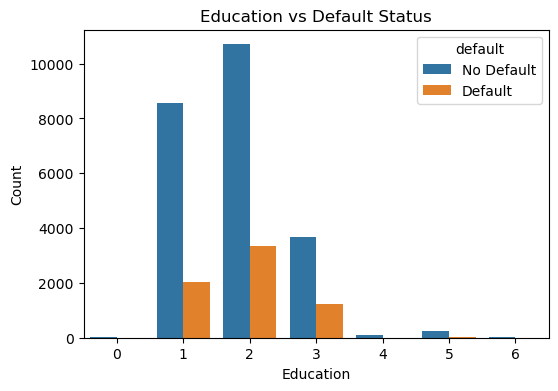

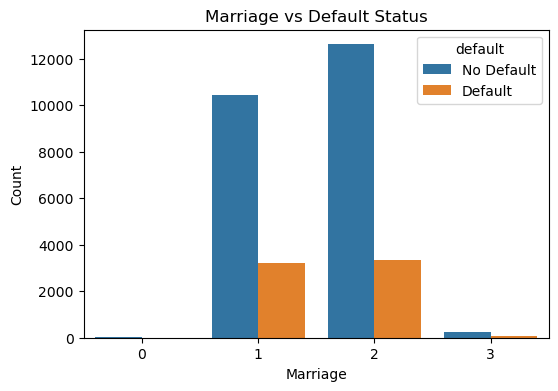

In [44]:
categorical_cols = ['sex', 'education', 'marriage']

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=plot_df, x = col, hue = target_col)
    plt.title(f"{col.title()} vs Default Status")
    plt.xlabel(col.title())
    plt.ylabel("Count")
    plt.legend(title='default')
    plt.show()

### Bill amount analysis ###

In [45]:
bill_cols = [col for col in df.columns if col.startswith('bill_amount')]

In [46]:
df[bill_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
bill_amount_sep,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
bill_amount_aug,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
bill_amount_jul,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
bill_amount_jun,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
bill_amount_may,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
bill_amount_apr,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0


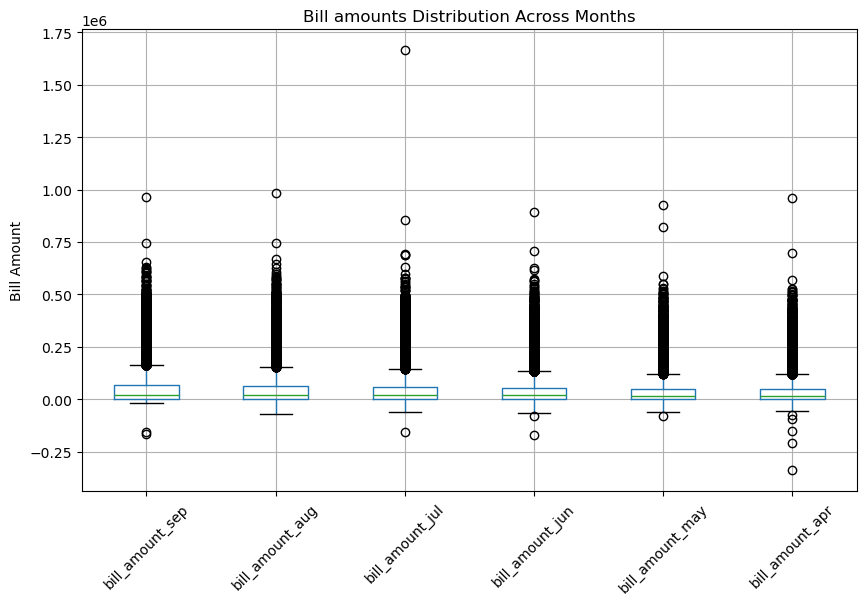

In [47]:
plt.figure(figsize =(10,6))
df[bill_cols].boxplot()
plt.title("Bill amounts Distribution Across Months")
plt.xticks(rotation=45)
plt.ylabel("Bill Amount")
plt.show()

### Payment amount analysis ###

In [48]:
payment_cols = [col for col in df.columns if col.startswith('payment_amount')]

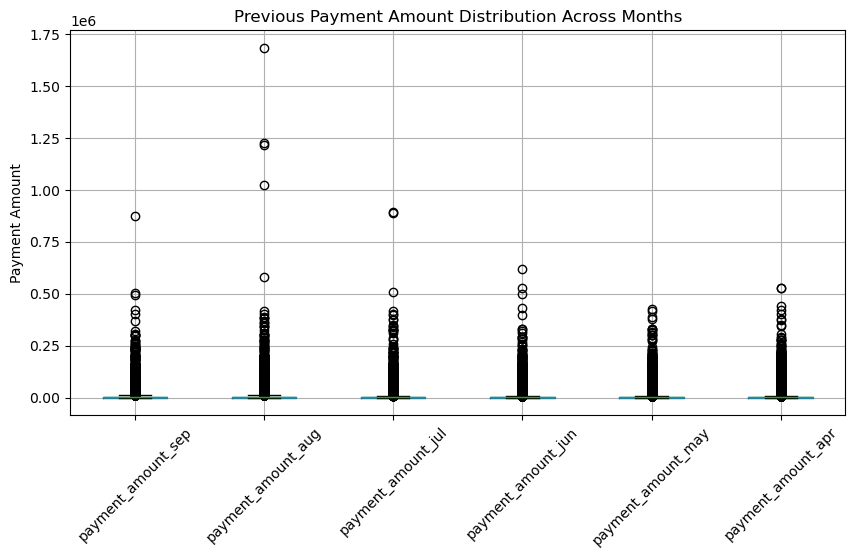

In [49]:
plt.figure(figsize=(10, 5))
df[payment_cols].boxplot()
plt.title("Previous Payment Amount Distribution Across Months")
plt.xticks(rotation=45)
plt.ylabel("Payment Amount")
plt.show()

### Correlation heatmap ###

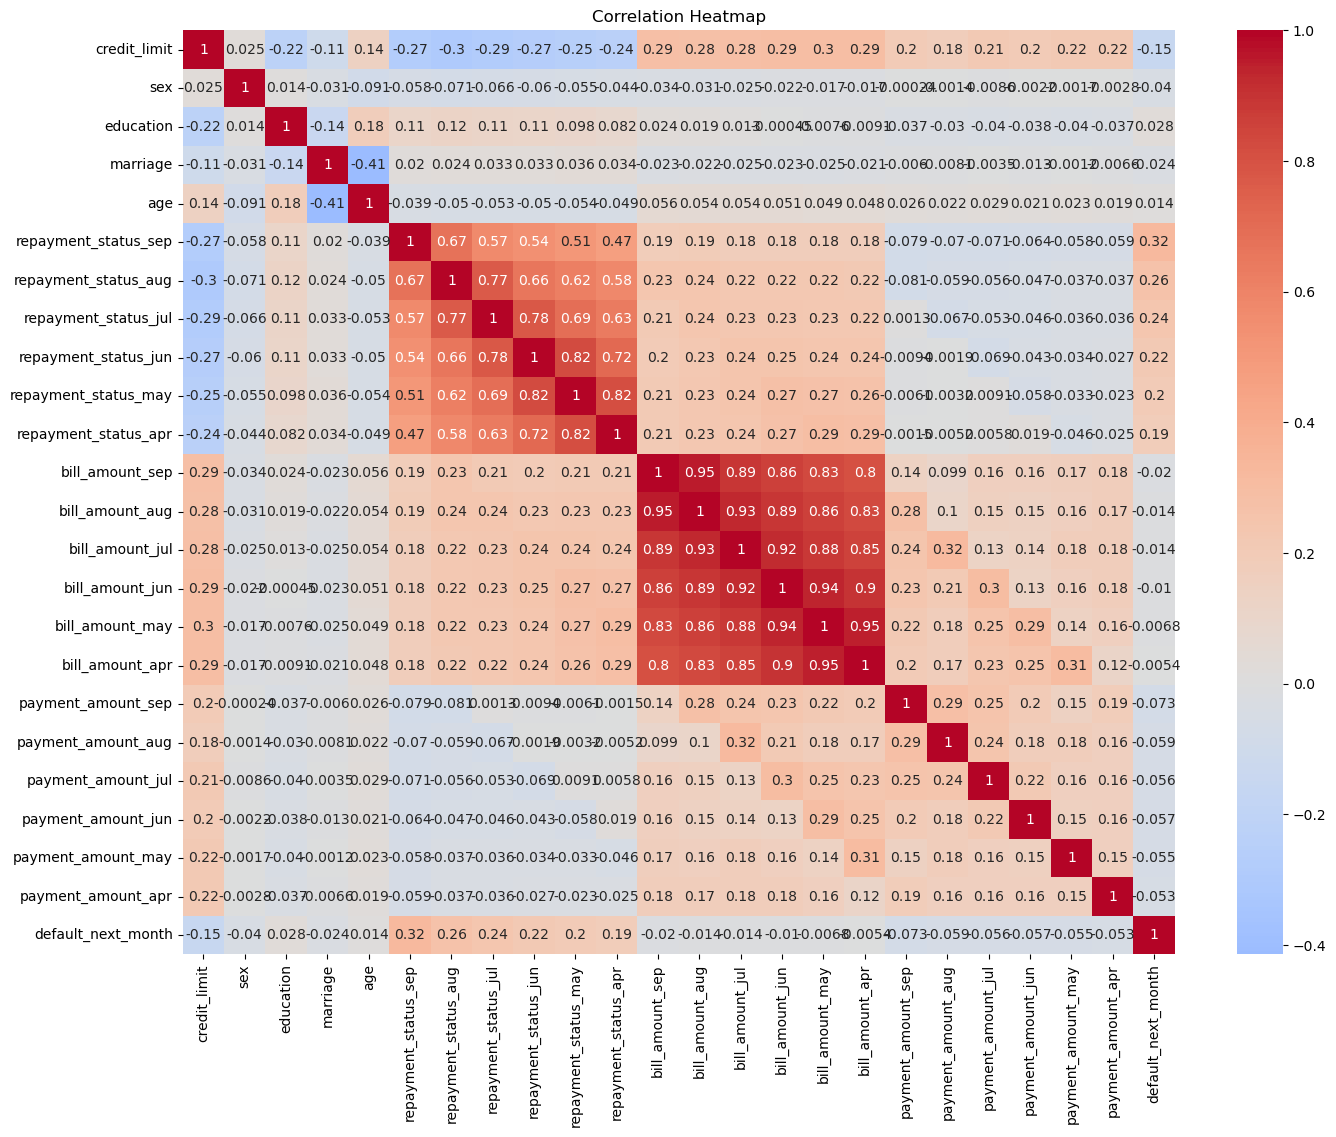

In [50]:
plt.figure(figsize=(16, 12))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

### Save cleaned dataset ###

In [51]:
processed_path = "../data/processed/credit_default_cleaned.csv"

df.to_csv(processed_path, index=False)

print(f"Cleaned dataset saved to: {processed_path}")

Cleaned dataset saved to: ../data/processed/credit_default_cleaned.csv


## EDA Summary

Key findings:

1. The dataset contains customer credit, demographic, repayment, bill, and payment information.
2. The target variable is imbalanced, with fewer default cases than non-default cases.
3. Repayment status variables appear to be highly relevant for default prediction.
4. Credit limit and payment behavior may also provide useful predictive signals.
5. Accuracy alone is not enough for evaluation because the target is imbalanced.
6. The next step is to build baseline and advanced classification models using Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost.